<div style='text-align: center;'>
<img src="images/math60082-banner.png" alt="image" width="80%" height="auto">
</div>

# Lab Workbook - Week 5

# Tasks

1. Write code to generate Monte Carlo approximations to a European call option with parameters $S_0=94.68$, $T=1$, $X=100$, $r=0.05$, $q=0.02$ and $\sigma=0.4$.

2. code up the Monte Carlo solver into a function

3. run the function several times with the same value of $N$, what do the results look like?

4. run the function for different values of $N=1000,2000,...$ and plot out the results, are they what you expected? Can you identify features of the graph?

5. calculate the exact value of the call option using numerical integration or the analytic formula, to be denoted $V_\text{exact}$

6. Estimate the value of $\eta$ for the call option, and plot the lines $$V_\text{exact}\pm\frac{\eta}{\sqrt{n}}$$ does the picture look like you would expect?

7. try running the same analysis on a put option, a binary option or any other payoff. Are the results always the same?

Following functions are required for the last part:

In [ ]:
import numpy
rng = numpy.random.default_rng(seed=0) # create a random number generator and reset the starting value
def monteCarlov1(S_0,T,X,r,q,sigma,n,K):
    dt = T/K
    dW = rng.normal(0.0,numpy.sqrt(dt),size=(n,K))
    sum = 0.0
    for i in range(0,n):
        St=S_0
        for k in range(0,K):
            St=St + (r-q)*St*dt + sigma*St*dW[i][k]
        sum += max(St-X,0.0)
    return sum/n *numpy.exp(-r*T)
def monteCarlov2(S_0,T,X,r,q,sigma,n):
    WT = rng.normal(0.0,numpy.sqrt(T), n)
    
    sum = 0.0
    for i in range(0,n):
        STi = S_0*numpy.exp((r-q-0.5*sigma*sigma)*T+sigma*WT[i])
        sum += max(STi-X,0.0)
    return sum/n *numpy.exp(-r*T)
def monteCarlov3(S_0,T,X,r,q,sigma,n):
    ST = rng.lognormal(numpy.log(S_0) + (r-q-0.5*sigma*sigma)*T, sigma*numpy.sqrt(T), n)
    sum = 0.0
    for i in range(0,n):
        sum += max(ST[i]-X,0.0)
    return sum/n *numpy.exp(-r*T)

8. Plot out the results of $V_n$ vs $n$ for each of the methods (you can choose $K=100$). Are the results converging on the correct value?

In [2]:
for i in range(0,10):
    print(monteCarlov1(100.0,1.0,100.0,0.05,0.02,0.2,100000,100))
    print(monteCarlov2(100.0,1.0,100.0,0.05,0.02,0.2,100000))
    print(monteCarlov3(100.0,1.0,100.0,0.05,0.02,0.2,100000))

9.168375575781877
9.252614933581864
9.163030678226871
9.28654514777001
9.241956082942238
9.297131587422207
9.2572523320132
9.266188372015506
9.173217590357371
9.168063468331288
9.238052678787833
9.266371915909033
9.281302198112309
9.305284756030739
9.274022470179144
9.269433885633893
9.231930313411794
9.246254615847235
9.137517555740692
9.156799780078494
9.150366625645256
9.2958722563885
9.242185198875841
9.268985924376699
9.218941478414418
9.28112095351238
9.237453473465859
9.24156711866066
9.278025075605406
9.23868923976003


9. Can you generate a confidence interval for a result with $n=1000000$ paths?

10. Run the code timings below -- can you explain why some codes take longer than others?

In [3]:
from timeit import timeit
n = 10000
K = 100
S_0=94.68
T=1
X=100
r=0.05
q=0.02
sigma=0.4

script="monteCarlov1(S_0,T,X,r,q,sigma,n,K)"
codeRuns = 100
timeSimulate = timeit( script,number=codeRuns,globals=globals() )

print("Time taken to run ",codeRuns," simulations with ",n," paths is", timeSimulate," seconds.")
script="monteCarlov2(S_0,T,X,r,q,sigma,n)"
codeRuns = 100
timeSimulate = timeit( script,number=codeRuns,globals=globals() )

print("Time taken to run ",codeRuns," simulations with ",n," paths is", timeSimulate," seconds.")
script="monteCarlov3(S_0,T,X,r,q,sigma,n)"
codeRuns = 100
timeSimulate = timeit( script,number=codeRuns,globals=globals() )

print("Time taken to run ",codeRuns," simulations with ",n," paths is", timeSimulate," seconds.")

Time taken to run  100  simulations with  10000  paths is 79.27080360008404  seconds.
Time taken to run  100  simulations with  10000  paths is 1.808030700078234  seconds.
Time taken to run  100  simulations with  10000  paths is 0.37914550001733005  seconds.


In [4]:
def monteCarlov4(S_0,T,X,r,q,sigma,n):
    ST = rng.lognormal(numpy.log(S_0) + (r-q-0.5*sigma*sigma)*T, sigma*numpy.sqrt(T), n)
    payoff = numpy.maximum(ST-X,0.0)
    return numpy.mean(payoff)*numpy.exp(-r*T)

In [5]:
script="monteCarlov4(S_0,T,X,r,q,sigma,n)"
codeRuns = 100
timeSimulate = timeit( script,number=codeRuns,globals=globals() )

print("Time taken to run ",codeRuns," simulations with ",n," paths is", timeSimulate," seconds.")

Time taken to run  100  simulations with  10000  paths is 0.056043999968096614  seconds.


11. Can you improve the run times using `numba` or `cython`?

In [ ]:
def monteCarloPlain(S_0,T,X,r,q,sigma,n,m):
    for j in range(0,m):
        WT = rng.normal(0.0,numpy.sqrt(T), n)
        # moment match on WT to ensure it has the correct mean and variance
        sum = 0.0
        for i in range(0,n):
            STi = S_0*numpy.exp((r-q-0.5*sigma*sigma)*T+sigma*WT[i])
            sum += max(STi-X,0.0)
        V_N =  sum/n *numpy.exp(-r*T)
    return # AVERAGE OF V_N VALUES with N*M total paths

In [9]:
def monteCarloAnti(S_0,T,X,r,q,sigma,n):
    WT = rng.normal(0.0,numpy.sqrt(T), n)
    sum = 0.0
    for i in range(0,n):
        STi = S_0*numpy.exp((r-q-0.5*sigma*sigma)*T+sigma*WT[i])
        STiminus = S_0*numpy.exp((r-q-0.5*sigma*sigma)*T-sigma*WT[i])
        sum += max(STi-X,0.0) + max(STiminus-X,0.0)
    return sum/2.0/n *numpy.exp(-r*T)

In [10]:
K=10000
N_values = numpy.zeros(K)
V_values = numpy.zeros(K)
VAnti_values = numpy.zeros(K)
for k in range(K):
    N = 1000 
    val = monteCarloPlain(S_0,T,X,r,q,sigma,N)
    V_values[k] = val
    VAnti_values[k] = monteCarloAnti(S_0,T,X,r,q,sigma,N)

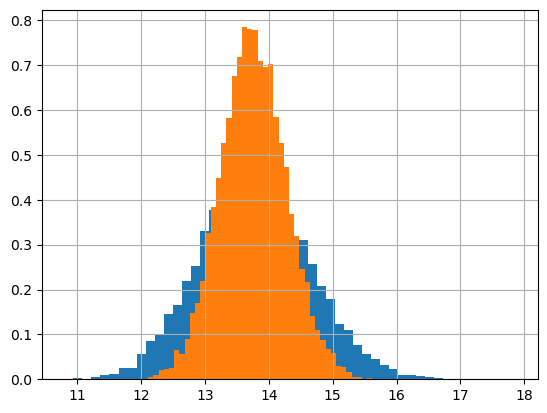

In [11]:
import matplotlib.pyplot as plt
plt.hist(V_values, bins=50,density=True)
plt.hist(VAnti_values, bins=50,density=True)
plt.grid(True)

In [12]:
var_V = numpy.var(V_values)
sample_mean_var = var_V/K
print(f"We can be 95% confident solution is within {numpy.average(V_values)-1.96*numpy.sqrt(sample_mean_var)} and {numpy.average(V_values)+1.96*numpy.sqrt(sample_mean_var)}.")

We can be 95% confident solution is within 13.751808695550542 and 13.785222229379405.


In [13]:
var_V = numpy.var(VAnti_values)
sample_mean_var = var_V/K
print(f"We can be 95% confident solution is within {numpy.average(VAnti_values)-1.96*numpy.sqrt(sample_mean_var)} and {numpy.average(VAnti_values)+1.96*numpy.sqrt(sample_mean_var)}.")

We can be 95% confident solution is within 13.748888347459923 and 13.769127675415609.


Consider asset value follows regime switching problem where
$$
dS = rS dt + \sigma(X)S dW
$$
and $X={L,H}$ is a continuous Markov chain with switching intensity
- $L \to H$ at continuous rate $\lambda$
- no switching back.

If the state is $X=L$, then $\sigma(L)=0.1$. If the state is $X=H$, then $\sigma(H)=0.4$.

The time to switch $h$ is exponentially distributed with $h\sim \mathrm{Exp}(\lambda)$.

Let's plot some stock paths. Assume each path is split into $K$ parts, so $\Delta t = T/K$, then
$$
S(t+\Delta t ) = S(t)\exp( (r-\frac12\sigma^2(X) )\Delta t + \sigma(X) \Delta W)
$$
The probability we switch at time $t$ is given by
$$
\text{Prob(switch low to high)} = \lambda \Delta t
$$
$$
\text{Prob(no switch)} = 1- \lambda \Delta t
$$

In [14]:
K = 1000
r = 0.01
sigma_L = 0.1
sigma_H = 0.4
lam = 1
T = 1

In [15]:
import numpy as np
from numpy import sqrt, exp, log

In [17]:
dt = T/K
dW = rng.normal(0,sqrt(dt),size=(K))
t_Values = np.zeros(K+1)
S_Values = np.zeros(K+1)
X_Values = np.zeros(K+1,dtype=int)
t_Values[0] = 0.0
S_Values[0] = 1.0
X_Values[0] = 0 # 0 means L and 1 means H
for k in range(K):
    if X_Values[k] == 0:
        sigma=sigma_L
    else:
        sigma=sigma_H

    t_Values[k+1] = (k+1)*dt
    S_Values[k+1] = S_Values[k]*exp((r - 0.5 * sigma**2) * dt + sigma * dW[k])
    xi = rng.uniform(0.,1.)
    if xi < lam*dt:
        X_Values[k+1] = 1
    else:
        X_Values[k+1] = X_Values[k]

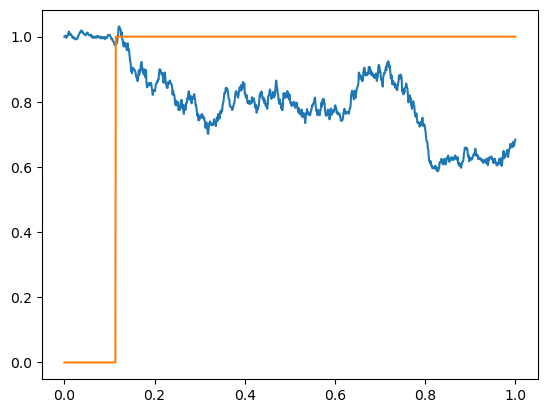

In [18]:
plt.plot(t_Values,S_Values)
plt.plot(t_Values,X_Values)

In [19]:
def monteCarloSwitching(S0,T,X,r,sigma_L,sigma_H,lam,n,K):
    sum = 0.0
    for j in range(0,n):
        dt = T/K
        dW = rng.normal(0,sqrt(dt),size=(K))
        t_Values = np.zeros(K+1)
        S_Values = np.zeros(K+1)
        X_Values = np.zeros(K+1,dtype=int)
        t_Values[0] = 0.0
        S_Values[0] = S0
        X_Values[0] = 0 # 0 means L and 1 means H
        for k in range(K):
            if X_Values[k] == 0:
                sigma=sigma_L
            else:
                sigma=sigma_H
    
            t_Values[k+1] = (k+1)*dt
            S_Values[k+1] = S_Values[k]*exp((r - 0.5 * sigma**2) * dt + sigma * dW[k])
            xi = rng.uniform(0.,1.)
            if xi < lam*dt:
                X_Values[k+1] = 1
            else:
                X_Values[k+1] = X_Values[k]
        sum = sum + max(S_Values[K]-X,0.0)
    return sum/n * exp(-r*T)

In [39]:
print(monteCarloSwitching(S0=1.0,T=1.0,X=1.0,r=0.01,sigma_L=0.1,sigma_H=0.4,lam=1,n=100000,K=200))

0.09461244038310979


In [42]:
def monteCarloSwitchingOneStep(S0,T,X,r,sigma_L,sigma_H,lam,n):
    sum = 0.0
    h = rng.exponential(1./lam,size=(n))
    sigmaHat = ( h*sigma_L + (T-h)*sigma_H )/T
    WT = rng.normal(0,sqrt(T),size=(n))
    ST = S0*exp((r - 0.5 * sigmaHat**2) * T + sigmaHat * WT)
    payoff = numpy.maximum(ST-X,0.0)
    return numpy.mean(payoff) * exp(-r*T)

In [43]:
print(monteCarloSwitchingOneStep(S0=1.0,T=1.0,X=1.0,r=0.01,sigma_L=0.1,sigma_H=0.4,lam=1,n=10000))

0.10571175544929072


In [44]:
def regimeSwitching():
    # generate tau_H times for each path
    
    # genarate WT and ST given tau_H on each path
    
    # calculate payoff and average


_IncompleteInputError: incomplete input (1071994722.py, line 6)